# EDA et feature engineering — détection de fraude

Analyse exploratoire du jeu `fraudTest.csv` et justification des features retenues pour le modèle. L'objectif est double : montrer que les variables choisies sont prédictives, et qu'elles sont toutes **calculables depuis une seule transaction** — condition nécessaire pour que le préprocessing soit identique à l'entraînement et au serving (absence de train/serve skew).

Le calcul des features réutilise directement `src/features.py` : aucune logique n'est dupliquée ici.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rendre le notebook exécutable quelle que soit la racine d'exécution.
RACINE = Path.cwd()
if RACINE.name == 'notebooks':
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

from src.features import (
    COLONNES_CATEGORIELLES,
    COLONNES_NUMERIQUES,
    calculer_distance_haversine,
    construire_features,
)

CHEMIN_CSV = RACINE / 'data' / 'fraudTest.csv'
df = pd.read_csv(CHEMIN_CSV)
print(f'{len(df):,} transactions chargées')

555,719 transactions chargées


## Aperçu du dataset

Dimensions, types de colonnes et premières lignes.

In [2]:
print('Dimensions :', df.shape)
display(df.dtypes)
df.head()

Dimensions : (555719, 23)


Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


## Déséquilibre des classes

La fraude est un événement rare : moins de 0,4 % des transactions. C'est le point déterminant de la stratégie de modélisation (voir conclusion).

is_fraud
0    553574
1      2145
Name: count, dtype: int64
Proportion de fraudes : 0.386%


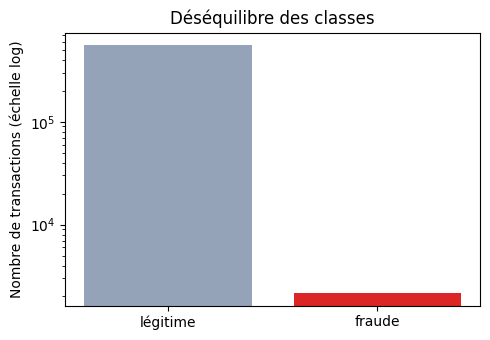

In [3]:
comptes = df['is_fraud'].value_counts().sort_index()
print(comptes)
print(f"Proportion de fraudes : {df['is_fraud'].mean():.3%}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['légitime', 'fraude'], comptes.values, color=['#94A3B8', '#DC2626'])
ax.set_yscale('log')
ax.set_ylabel('Nombre de transactions (échelle log)')
ax.set_title('Déséquilibre des classes')
plt.tight_layout(); plt.show()

## Matrice de features réelle

Les features sont construites par `construire_features`, exactement comme à l'entraînement et au serving. On y attache le label `is_fraud` (uniquement pour l'analyse, jamais comme variable d'entrée).

In [4]:
features = construire_features(df)
features['is_fraud'] = df['is_fraud'].values
print('Features :', COLONNES_CATEGORIELLES + COLONNES_NUMERIQUES)
features.head()

Features : ['category', 'gender', 'amt', 'city_pop', 'age', 'hour', 'day_of_week', 'is_night', 'is_weekend', 'distance_km']


,category,gender,amt,city_pop,age,hour,day_of_week,is_night,is_weekend,distance_km,is_fraud
0,personal_care,M,2.86,333497,52.257358,12,6,0,1,24.561462,0
1,personal_care,F,29.84,302,30.425736,12,6,0,1,104.925092,0
2,health_fitness,F,41.28,34496,49.667351,12,6,0,1,59.080078,0
3,misc_pos,M,60.05,54767,32.908966,12,6,0,1,27.698567,0
4,travel,M,3.19,1126,64.960986,12,6,0,1,104.335106,0


## Distribution du montant (`amt`)

Vue globale (tronquée au 99e centile) puis comparaison fraude vs légitime. Les fraudes se concentrent sur des montants nettement plus élevés en médiane.

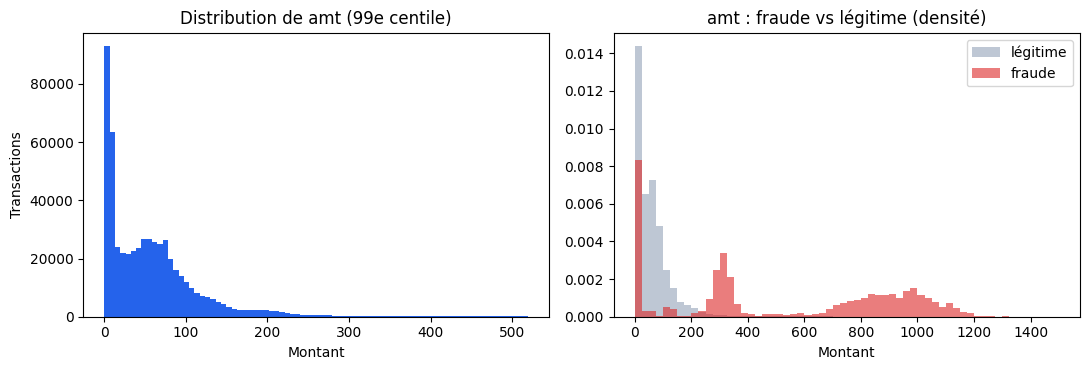

Montant médian par classe :
is_fraud
0     47.15
1    371.94
Name: amt, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(features['amt'], bins=80, range=(0, features['amt'].quantile(0.99)), color='#2563EB')
axes[0].set_title('Distribution de amt (99e centile)')
axes[0].set_xlabel('Montant'); axes[0].set_ylabel('Transactions')

for label, couleur, nom in [(0, '#94A3B8', 'légitime'), (1, '#DC2626', 'fraude')]:
    sous = features.loc[features['is_fraud'] == label, 'amt']
    axes[1].hist(sous, bins=60, range=(0, 1500), density=True, alpha=0.6, color=couleur, label=nom)
axes[1].set_title('amt : fraude vs légitime (densité)')
axes[1].set_xlabel('Montant'); axes[1].legend()
plt.tight_layout(); plt.show()

print('Montant médian par classe :')
print(features.groupby('is_fraud')['amt'].median())

## Taux de fraude par catégorie marchande

Certaines catégories (achats en ligne, notamment) concentrent une part de fraude bien supérieure à la moyenne : `category` est donc discriminante.

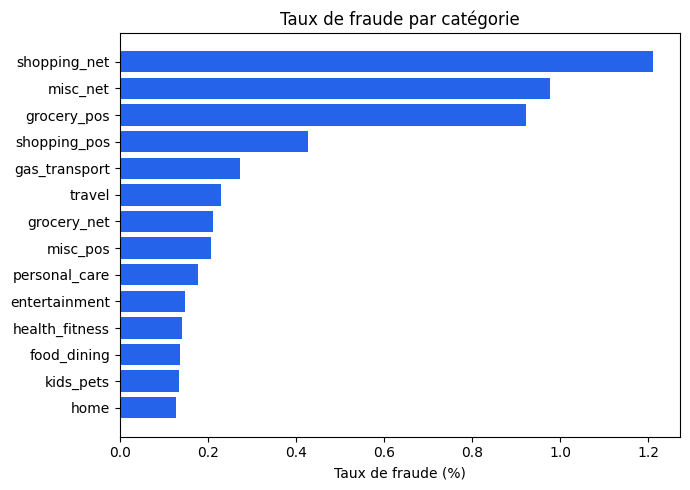

In [6]:
taux_cat = features.groupby('category')['is_fraud'].mean().sort_values() * 100
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(taux_cat.index, taux_cat.values, color='#2563EB')
ax.set_xlabel('Taux de fraude (%)')
ax.set_title('Taux de fraude par catégorie')
plt.tight_layout(); plt.show()

## Variables temporelles : heure, nuit, week-end

Dérivées de l'horodatage (`trans_date_trans_time` à l'entraînement, `current_time` au serving). Le taux de fraude est nettement plus élevé la nuit.

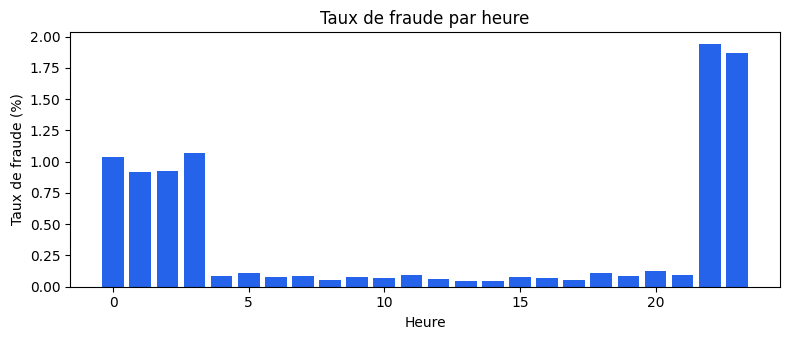

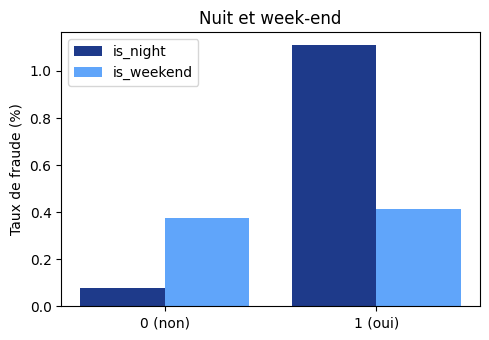

In [7]:
taux_heure = features.groupby('hour')['is_fraud'].mean() * 100
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(taux_heure.index, taux_heure.values, color='#2563EB')
ax.set_xlabel('Heure'); ax.set_ylabel('Taux de fraude (%)')
ax.set_title('Taux de fraude par heure')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 3.5))
nuit = features.groupby('is_night')['is_fraud'].mean() * 100
weekend = features.groupby('is_weekend')['is_fraud'].mean() * 100
x = np.arange(2)
ax.bar(x - 0.2, [nuit.get(0, 0), nuit.get(1, 0)], width=0.4, label='is_night', color='#1E3A8A')
ax.bar(x + 0.2, [weekend.get(0, 0), weekend.get(1, 0)], width=0.4, label='is_weekend', color='#60A5FA')
ax.set_xticks(x); ax.set_xticklabels(['0 (non)', '1 (oui)'])
ax.set_ylabel('Taux de fraude (%)'); ax.set_title('Nuit et week-end'); ax.legend()
plt.tight_layout(); plt.show()

## Distance Haversine client–marchand

`distance_km` est produite par `construire_features`, qui appelle `calculer_distance_haversine` : le calcul n'est pas dupliqué ici. Les fraudes présentent des écarts géographiques différents des transactions légitimes.

Contrôle distance 1re transaction : 24.6 km (feature : 24.6 km)


/tmp/claude-501/ipykernel_8671/514051677.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(donnees, labels=['légitime', 'fraude'], showfliers=False)


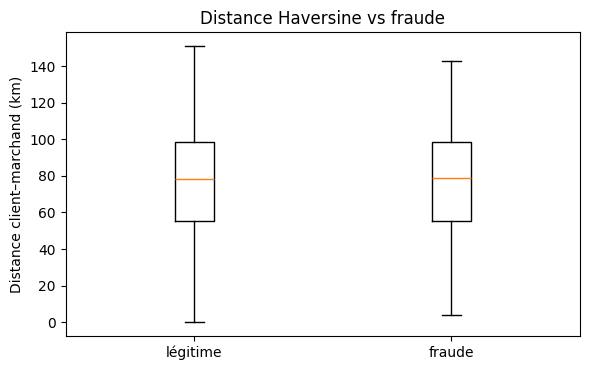

is_fraud
0    78.178918
1    78.593368
Name: distance_km, dtype: float64


In [8]:
# Vérification que la feature provient bien de la fonction partagée.
controle = calculer_distance_haversine(
    df['lat'].iloc[0], df['long'].iloc[0], df['merch_lat'].iloc[0], df['merch_long'].iloc[0]
)
print(f'Contrôle distance 1re transaction : {controle:.1f} km '
      f"(feature : {features['distance_km'].iloc[0]:.1f} km)")

donnees = [features.loc[features['is_fraud'] == 0, 'distance_km'],
           features.loc[features['is_fraud'] == 1, 'distance_km']]
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.boxplot(donnees, labels=['légitime', 'fraude'], showfliers=False)
ax.set_ylabel('Distance client–marchand (km)')
ax.set_title('Distance Haversine vs fraude')
plt.tight_layout(); plt.show()

print(features.groupby('is_fraud')['distance_km'].median())

## Âge du porteur et population de la ville

`age` (dérivé de `current_time - dob`) et `city_pop` complètent le profil de la transaction. On observe une variation du taux de fraude selon ces axes.

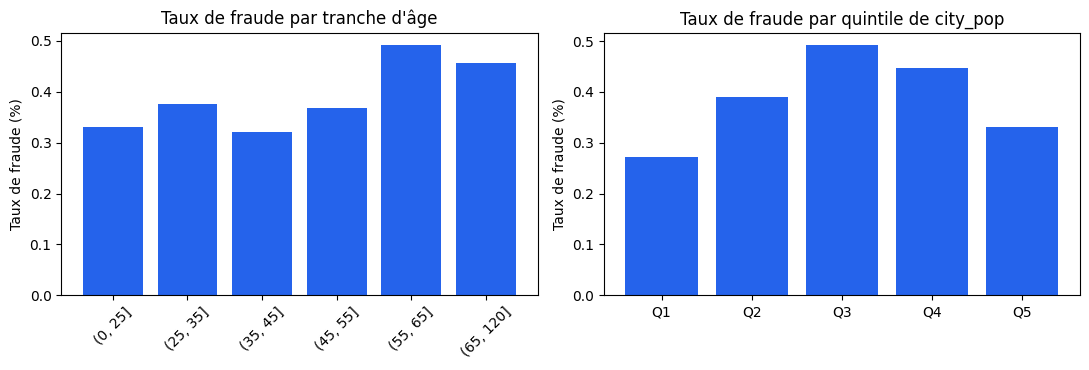

In [9]:
tranches_age = pd.cut(features['age'], bins=[0, 25, 35, 45, 55, 65, 120])
taux_age = features.groupby(tranches_age, observed=True)['is_fraud'].mean() * 100
tranches_pop = pd.qcut(features['city_pop'], q=5, duplicates='drop')
taux_pop = features.groupby(tranches_pop, observed=True)['is_fraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar([str(i) for i in taux_age.index], taux_age.values, color='#2563EB')
axes[0].set_title("Taux de fraude par tranche d'âge"); axes[0].set_ylabel('Taux de fraude (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar([f'Q{i + 1}' for i in range(len(taux_pop))], taux_pop.values, color='#2563EB')
axes[1].set_title('Taux de fraude par quintile de city_pop'); axes[1].set_ylabel('Taux de fraude (%)')
plt.tight_layout(); plt.show()

## Justification des features

Chaque feature retenue est à la fois prédictive (vu ci-dessus) et **calculable depuis une seule transaction de l'API**, ce qui garantit un préprocessing identique entre entraînement et production.

- **`amt`** — le montant. Les fraudes ciblent des montants atypiques ; disponible immédiatement.
- **`category`** — type de marchand. Forte variation du taux de fraude entre catégories ; encodée en one-hot.
- **`gender`, `city_pop`** — attributs présents dans chaque transaction.
- **`age`** = `current_time - dob`, dérivable directement et stable.
- **`hour`, `day_of_week`, `is_night`, `is_weekend`** — dérivées de l'horodatage. La sémantique (heure de la journée, week-end) est transférable : `trans_date_trans_time` à l'entraînement, `current_time` au serving.
- **`distance_km`** — distance Haversine entre le porteur et le marchand. Signal géographique fort, calculable depuis `lat/long/merch_lat/merch_long` d'une seule transaction, sans aucun skew.

### Variables écartées

- **`unix_time`** : absent au serving (l'API ne le renvoie pas).
- **`trans_num`, `cc_num`, noms, adresse** : identifiants sans pouvoir généralisant, et sources de fuite.
- **Features comportementales par client** (vélocité, dépense moyenne par `cc_num`) : l'API renvoie des transactions isolées au hasard, on ne revoit jamais le même porteur. Ces variables seraient **toujours vides au serving** → skew garanti. Elles relèveraient d'un feature store (évolution possible), pas de ce périmètre.

## Conclusion

**Features.** Les variables retenues sont prédictives et toutes calculables depuis une transaction unique. Elles sont encapsulées dans un `Pipeline` scikit-learn unique (feature engineering + encodage + modèle), sérialisé en un seul `.joblib` : le même objet sert à l'entraînement et au serving, ce qui supprime tout risque de train/serve skew.

**Déséquilibre (~0,386 % de fraudes).** La stratégie en découle :

- split stratifié train/test ;
- `class_weight='balanced'` dans le Random Forest ;
- seuil de décision à **0,30** : une notification ne coûte qu'un e-mail, on privilégie donc le rappel ;
- évaluation sur **PR-AUC, rappel et F1**, pas sur l'accuracy, trompeuse sur des données aussi déséquilibrées.